# IBM HR Attrition — Exploratory Data Analysis

Quick visual exploration of the raw dataset before the SQL and survival-model
phases. This notebook works directly off `data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv`
(no synthetic fields) — for the full analysis see
[`docs/sql_findings.md`](../docs/sql_findings.md) and
[`docs/survival_model_findings.md`](../docs/survival_model_findings.md).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv", encoding="utf-8-sig")
df.shape

(1470, 35)

## Shape and attrition balance

In [2]:
df["Attrition"].value_counts(normalize=True).mul(100).round(1)

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

16.1% attrition, consistent with `sql/results/01_overall_attrition_rate.csv`.
This is an imbalanced target — worth keeping in mind for the survival model's
concordance index, which is somewhat easier to score well on with an
imbalanced event rate than a 50/50 split would be.

## Income by attrition, split by overtime

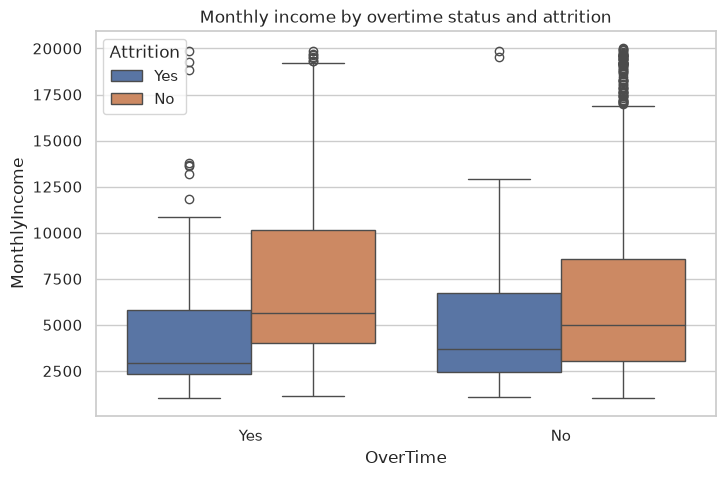

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="OverTime", y="MonthlyIncome", hue="Attrition", ax=ax)
ax.set_title("Monthly income by overtime status and attrition")
plt.show()

Leavers skew toward lower income within both overtime groups, and the
overtime=Yes group's income distribution isn't obviously different from
overtime=No — income and overtime look like two largely independent risk
factors rather than one explaining the other, matching the survival model
treating them as separate covariates rather than one being a proxy for the other.

## Attrition rate by tenure (year-by-year, not bucketed)

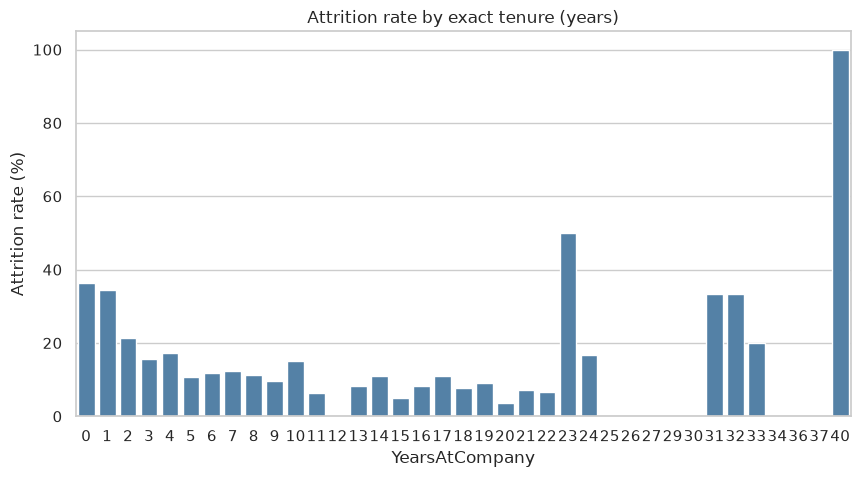

In [4]:
by_year = (
    df.groupby("YearsAtCompany")["Attrition"]
    .apply(lambda s: 100 * (s == "Yes").mean())
    .reset_index(name="attrition_rate_pct")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=by_year, x="YearsAtCompany", y="attrition_rate_pct", ax=ax, color="steelblue")
ax.set_title("Attrition rate by exact tenure (years)")
ax.set_ylabel("Attrition rate (%)")
plt.show()

Year-by-year (rather than bucketed) view shows the front-loaded pattern from
`docs/sql_findings.md` isn't a smooth decline — years 0-2 are consistently high,
then it's noisy at low headcount per year past year 10 (small-sample bars,
not necessarily a real signal).

## Correlation among numeric features

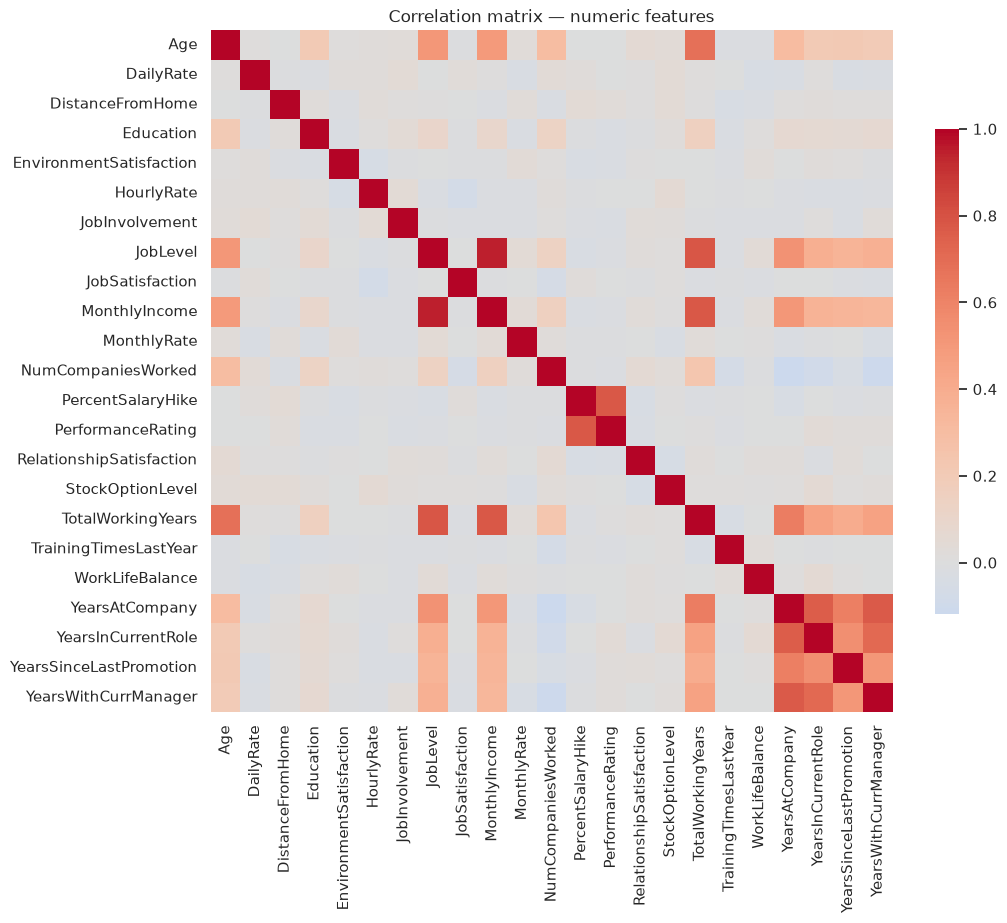

In [5]:
numeric_cols = df.select_dtypes("number").columns.drop(
    ["EmployeeCount", "EmployeeNumber", "StandardHours"]  # constant/ID columns, not informative
)
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation matrix — numeric features")
plt.show()

`JobLevel`, `MonthlyIncome`, `TotalWorkingYears`, and `YearsAtCompany` are all
strongly correlated with each other, as expected (more senior, longer-tenured
employees earn more) — the survival model's `penalizer=0.1` ridge term exists
partly to handle this collinearity rather than let it inflate individual
coefficient variance. See `DECISIONS.md` for the modeling choices this motivated.